# Семинар 10, часть 2 - Трекинг

**Домашнее задание**

***

In [1]:
!pip install torch==1.13.1+cu116 torchvision==0.14.1+cu116 --extra-index-url https://download.pytorch.org/whl/cu116
!pip install ultralytics filterpy lap
!pip uninstall -y numpy protobuf
!pip install -U numpy==1.23.5 protobuf==3.20.3

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu116
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 GB 549.7 kB/s eta 0:00:000:0100:04
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.2/24.2 MB 13.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: torch
    Found existing installation: torch 2.6.0+cu126
    Uninstalling torch-2.6.0+cu126:
      Successfully uninstalled torch-2.6.0+cu126
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.21.0+cu126
    Uninstalling torchvision-0.21.0+cu126:
      Successfully uninstalled torchvision-0.21.0+cu126
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.6.0+cu126 requires torch==2.6.0, but you have torch 1.13.1+cu116 which is incompatible.
accelerate 1.5.2 requir

In [1]:
from typing import Tuple
from time import time
import types
from pathlib import Path

from scipy.optimize import linear_sum_assignment
import numpy as np
import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO

/home/panzer/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Вспомогательные функции

In [2]:
def show_image(img: np.ndarray) -> None:
    plt.figure(figsize=(10,5))
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.show()


def detection_visualization(
    img_path: Path, preds: np.ndarray
) -> np.ndarray:
    img = cv2.imread(str(img_path)) # Read image with cv2
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
    for i in range(len(preds)):
        cv2.rectangle(
            img,
            (int(preds[i][0]), int(preds[i][1])),
            (int(preds[i][2]), int(preds[i][3])),
            color=(0, 255, 0),
            thickness=3,
        )
    return img


def tracking_visualization(
    img_path: Path, preds: np.ndarray
) -> np.ndarray:
    img = cv2.imread(str(img_path)) # Read image with cv2
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
    for i in range(len(preds)):
        cv2.rectangle(
            img,
            (int(preds[i][0]), int(preds[i][1])),
            (int(preds[i][2]), int(preds[i][3])),
            color=(0, 255, 0),
            thickness=3,
        )
        cv2.putText(
            img,
            str(int(preds[i][4])),
            (int(preds[i][0]), int(preds[i][1])),
            cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=2,
            color=(0, 255, 0),
            thickness=3
        )
    return img


# Датасет

В рамках данного семинара мы будем использовать трек `MOT17-09` из датасета MOT Challenge https://motchallenge.net/

Ссылка на скачивание датасета https://motchallenge.net/data/MOT17Det/

In [3]:
dataset_dir = Path("./MOT17-09/img1")  # путь к директории с изображениями трека MOT17-09
frames_list = sorted([f for f in dataset_dir.iterdir()])

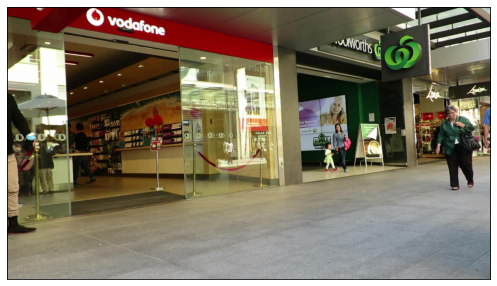

In [4]:
img = cv2.cvtColor(cv2.imread(str(frames_list[0])), cv2.COLOR_BGR2RGB)
show_image(img)

# Детекция с помощью YOLOv8

В качестве бэкбона детекции мы будем использовать YOLOv8s из библиотеки ultralytics: https://github.com/ultralytics/ultralytics

In [17]:
class YoloDetector:
    def __init__(self, conf_threshold: float = 0.5) -> None:
        self.backbone = YOLO("yolov8s.pt")
        self.conf_threshold = conf_threshold

    def __call__(self, img_path: Path) -> np.ndarray:
        preds = self.backbone.predict(source=img_path, conf=self.conf_threshold, show=False, classes=0)
        preds = preds[0].boxes.data.cpu().numpy()[:, :5]
        return preds


image 1/1 /home/panzer/git/cv_course_2025/seminars/seminar_11/MOT17-09/img1/000001.jpg: 384x640 7 persons, 86.6ms
Speed: 28.4ms preprocess, 86.6ms inference, 26.2ms postprocess per image at shape (1, 3, 384, 640)


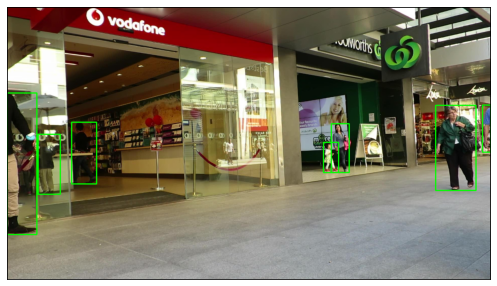

In [19]:
detector = YoloDetector()
preds = detector(frames_list[0])

out_frame = detection_visualization(frames_list[0], preds)
show_image(out_frame)

# Алгоритм трекинга SORT

SORT: https://arxiv.org/abs/1602.00763

Разделы "3.3. Data Association" и "3.4. Creation and Deletion of Track Identities" описывают алгоритм соотнесения результатов детекции последовательных кадров:

> **3.3. Data Association**
>
> In assigning detections to existing targets, each target’s
> bounding box geometry is estimated by predicting its new
> location in the current frame. The assignment cost matrix is
> then computed as the intersection-over-union (IOU) distance
> between each detection and all predicted bounding boxes
> from the existing targets. The assignment is solved optimally
> using the Hungarian algorithm. Additionally, a minimum
> IOU is imposed to reject assignments where the detection to
> target overlap is less than $IOU_{min}$.
>
> We found that the IOU distance of the bounding boxes
> implicitly handles short term occlusion caused by passing targets.
> Specifically, when a target is covered by an occluding
> object, only the occluder is detected, since the IOU distance
> appropriately favours detections with similar scale. This allows
> both the occluder target to be corrected with the detection while
> the covered target is unaffected as no assignment is made.

> **3.4. Creation and Deletion of Track Identities**
>
> When objects enter and leave the image, unique identities
> need to be created or destroyed accordingly. For creating
> trackers, we consider any detection with an overlap less than
> $IOU_{min}$ to signify the existence of an untracked object. The
> tracker is initialised using the geometry of the bounding box
> with the velocity set to zero. Since the velocity is unobserved
> at this point the covariance of the velocity component is initialised
> with large values, reflecting this uncertainty. Additionally, the new
> tracker then undergoes a probationary period where the target needs
> to be associated with detections to accumulate enough evidence in order
> to prevent tracking of false positives.
>
> Tracks are terminated if they are not detected for $T_{Lost}$
> frames. This prevents an unbounded growth in the number
> of trackers and localisation errors caused by predictions over
> long durations without corrections from the detector. In all
> experiments $T_{Lost}$ is set to 1 for two reasons. Firstly, the constant
> velocity model is a poor predictor of the true dynamics
> and secondly we are primarily concerned with frame-to-frame
> tracking where object re-identification is beyond the scope of
> this work. Additionally, early deletion of lost targets aids efficiency.
> Should an object reappear, tracking will implicitly resume under a new identity.

# Венгерский алгоритм (Hungarian algorithm)

- [Wikipedia](https://en.wikipedia.org/wiki/Hungarian_algorithm)
- Реализация в библиотеке scipy: [`scipy.optimize.linear_sum_assignment`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html)
- Реализация в библиотеке [lap](https://github.com/gatagat/lap): `lap.lapjv`

## Задание 1:

Реализуйте Венгерский алгоритм. Сравните возвращаемые значения с библиотечной функцией [`scipy.optimize.linear_sum_assignment`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html).

In [20]:
def hungarian_algorithm(cost_matrix: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Solves the assignment problem using the Hungarian algorithm.

    Args:
        cost_matrix (np.ndarray): Numpy array of shape (n, m) representing the cost matrix.

    Returns:
        A tuple of two numpy arrays (row_ind, col_ind) representing the row and column indices
        of the assigned cells in the cost matrix.
    """
    # Implementation of the Hungarian algorithm (Munkres algorithm)
    # This implementation works for rectangular matrices by padding with large values

    cost = cost_matrix.copy()
    n_rows, n_cols = cost.shape
    n = max(n_rows, n_cols)
    # Pad the cost matrix to make it square
    padded_cost = np.full((n, n), cost.max() + 1, dtype=cost.dtype)
    padded_cost[:n_rows, :n_cols] = cost

    # Step 1: Subtract row minima
    for i in range(n):
        padded_cost[i] -= padded_cost[i].min()

    # Step 2: Subtract column minima
    for j in range(n):
        padded_cost[:, j] -= padded_cost[:, j].min()

    # Step 3: Cover all zeros with minimum number of lines
    # and test for optimality, otherwise adjust the matrix and repeat
    def find_zero(pad, covered_rows, covered_cols):
        for i in range(n):
            if not covered_rows[i]:
                for j in range(n):
                    if not covered_cols[j] and pad[i, j] == 0:
                        return i, j
        return None

    # Starred zeros: assignment
    starred = np.zeros((n, n), dtype=bool)
    row_covered = np.zeros(n, dtype=bool)
    col_covered = np.zeros(n, dtype=bool)

    # Step 3: Star zeros
    for i in range(n):
        for j in range(n):
            if padded_cost[i, j] == 0 and not row_covered[i] and not col_covered[j]:
                starred[i, j] = True
                row_covered[i] = True
                col_covered[j] = True
    row_covered[:] = False
    col_covered[:] = False

    # Step 4: Cover columns with starred zeros
    for j in range(n):
        if np.any(starred[:, j]):
            col_covered[j] = True

    def cover_count():
        return np.sum(col_covered)

    while cover_count() < n:
        # Step 5: Find a noncovered zero and prime it
        # If no such zero, go to Step 6
        # If there is, prime it and check for starred zero in the row
        # If yes, cover the row and uncover the column, repeat
        # If not, go to Step 7
        primed = np.zeros((n, n), dtype=bool)
        done = False
        while not done:
            z = find_zero(padded_cost, row_covered, col_covered)
            if z is None:
                # Step 6: Adjust the matrix
                uncovered_rows = ~row_covered
                uncovered_cols = ~col_covered
                minval = np.min(padded_cost[uncovered_rows][:, uncovered_cols])
                # Add minval to covered rows
                padded_cost[row_covered] += minval
                # Subtract minval from uncovered columns
                padded_cost[:, ~col_covered] -= minval
            else:
                i, j = z
                primed[i, j] = True
                # If there is a starred zero in the same row
                star_col = np.where(starred[i])[0]
                if star_col.size > 0:
                    row_covered[i] = True
                    col_covered[star_col[0]] = False
                else:
                    # Step 7: Augmenting path
                    # Construct the sequence of alternating primed and starred zeros
                    path = [(i, j)]
                    while True:
                        star_row = np.where(starred[:, path[-1][1]])[0]
                        if star_row.size == 0:
                            break
                        path.append((star_row[0], path[-1][1]))
                        prime_col = np.where(primed[path[-1][0]])[0]
                        path.append((path[-1][0], prime_col[0]))
                    # Unstar each starred zero of the path, star each primed zero
                    for r, c in path:
                        starred[r, c] = not starred[r, c]
                    # Clear all covers and primes
                    row_covered[:] = False
                    col_covered[:] = False
                    primed[:, :] = False
                    # Cover columns with starred zeros
                    for j in range(n):
                        if np.any(starred[:, j]):
                            col_covered[j] = True
                    done = True

    # Now, extract the assignments
    row_ind, col_ind = np.where(starred[:n_rows, :n_cols])
    return row_ind, col_ind


In [21]:
cost_matrix = np.array([[1, 2, 3],
                        [4, 5, 6],
                        [7, 8, 9]])
my_row_ind, my_col_ind = hungarian_algorithm(cost_matrix)
my_cost = cost_matrix[my_row_ind, my_col_ind].sum()
row_ind, col_ind = linear_sum_assignment(cost_matrix)
cost = cost_matrix[row_ind, col_ind].sum()

assert my_cost == cost

# Алгоритм трекинга ByteTrack

- Статья https://arxiv.org/abs/2110.06864
- Код https://github.com/ifzhang/ByteTrack


## Вопрос 1:

В чем заключается ключевая особенность метода BYTE?

**Ответ:**

В треккинге боксов большой и малой уверенности, а не только большой уверенности, как у всех.

In [22]:
# !git clone https://github.com/ifzhang/ByteTrack.git
# %cd ByteTrack
# !pip install -r requirements.txt
# !python setup.py develop
# %cd ..
# !pip install cython
# !pip install 'git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI'
# !pip install cython_bbox

In [46]:
from ultralytics.trackers.byte_tracker import BYTETracker
import cv2 
from ultralytics import YOLO

fps = 30
frame_size = (1080, 1920)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_file = 'output.mp4'
video_writer = cv2.VideoWriter(output_file, fourcc, fps, frame_size[::-1])

args = types.SimpleNamespace(**{
    "track_low_thresh": 0.1,
    "track_high_thresh": 0.25,
    "track_buffer": 30,
    "match_thresh": 0.8,
    "track_high_thresh": 0.25, # threshold for the first association
    "track_low_thresh": 0.1, # threshold for the second association
    "new_track_thresh": 0.25, # threshold for init new track if the detection does not match any tracks
    "fuse_score": True, # Whether to fuse confidence scores with the iou distances before matching


})
tracker = BYTETracker(args, frame_rate=fps)

det_times = []
track_times = []

model = YOLO("yolo11n.yaml").load("yolo11n.pt")  # build from YAML and transfer weights

for frame_path in frames_list:
    s_time = time()
    detections = model(frame_path)[0].boxes.cpu()
    det_times.append((time() - s_time) * 1000)  # in ms
    s_time = time()
    tracks = tracker.update(detections, frame_size, frame_size)
    track_times.append((time() - s_time) * 1000)  # in ms
    out_frame = tracking_visualization(frame_path, tracks)
    video_writer.write(cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))
    # cv2.imwrite(f"./output/{str(frame_path.name)}", cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))
video_writer.release()

print(f"mean detection time: {np.mean(det_times)}, mean track time: {np.mean(track_times)}")

Transferred 499/499 items from pretrained weights

image 1/1 /home/panzer/git/cv_course_2025/seminars/seminar_11/MOT17-09/img1/000001.jpg: 384x640 7 0s, 1 56, 43.8ms
Speed: 3.4ms preprocess, 43.8ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/panzer/git/cv_course_2025/seminars/seminar_11/MOT17-09/img1/000002.jpg: 384x640 7 0s, 2 56s, 36.9ms
Speed: 3.5ms preprocess, 36.9ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/panzer/git/cv_course_2025/seminars/seminar_11/MOT17-09/img1/000003.jpg: 384x640 9 0s, 2 56s, 37.5ms
Speed: 4.5ms preprocess, 37.5ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/panzer/git/cv_course_2025/seminars/seminar_11/MOT17-09/img1/000004.jpg: 384x640 8 0s, 1 56, 37.7ms
Speed: 4.4ms preprocess, 37.7ms inference, 3.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/panzer/git/cv_course_2025/seminars/seminar_11/MOT17-09/img1/000005.jpg: 384x640

## Задание 2

Объедините BYTE и любой трекер с Re-ID признаками (например, FairMOT). Можно воспользоваться инструкциями из репозитория: https://github.com/ifzhang/ByteTrack/tree/main/tutorials

Ответом на это задание должен быть код, записывающий видео работы метода для трека MOT17-09 в файл `reid_out.mp4`. Убедитесь, что код работает "end-to-end".

In [6]:
#simplex sigillum veri	
from torch import nn
from ultralytics import YOLO
import cv2
import numpy as np

model = YOLO("yolo11n.pt")
# Определим параметры видео
first_frame = cv2.imread(str(frames_list[0]))
height, width = first_frame.shape[:2]
fps = 30 

video_writer = cv2.VideoWriter(
    "reid_out.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

# Функция для отрисовки треков поверх кадров
def draw_tracks_on_frame(frame, boxes, ids):
    for box, track_id in zip(boxes, ids):
        x1, y1, x2, y2 = map(int, box)
        color = (int(track_id * 37) % 256, int(track_id * 17) % 256, int(track_id * 29) % 256)
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, f'ID {track_id}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return frame

# Проходимся по frame_list батчами по 100, у меня не хватает ОЗУ....
for i in range(0, len(frames_list), 100):
    batch_frames = frames_list[i:i+100]
    results = model.track(batch_frames, stream=False, tracker="bytetrack_reid.yaml")
    # results - список Results, по одному на каждый кадр
    for idx, res in enumerate(results):
        frame = cv2.imread(str(batch_frames[idx]))
        if hasattr(res, "boxes") and res.boxes is not None and len(res.boxes) > 0:
            # Получаем координаты и id треков
            boxes = res.boxes.xyxy.cpu().numpy()
            ids = res.boxes.id.cpu().numpy().astype(int) if hasattr(res.boxes, "id") and res.boxes.id is not None else np.zeros(len(boxes), dtype=int)
            frame = draw_tracks_on_frame(frame, boxes, ids)
        video_writer.write(frame)

video_writer.release()



0: 384x640 7 persons, 1 chair, 3.6ms
1: 384x640 7 persons, 2 chairs, 3.6ms
2: 384x640 9 persons, 2 chairs, 3.6ms
3: 384x640 8 persons, 1 chair, 3.6ms
4: 384x640 7 persons, 1 chair, 3.6ms
5: 384x640 10 persons, 1 chair, 3.6ms
6: 384x640 8 persons, 1 chair, 3.6ms
7: 384x640 10 persons, 1 chair, 3.6ms
8: 384x640 9 persons, 2 chairs, 3.6ms
9: 384x640 10 persons, 2 chairs, 3.6ms
10: 384x640 13 persons, 2 chairs, 3.6ms
11: 384x640 12 persons, 2 chairs, 3.6ms
12: 384x640 11 persons, 2 chairs, 3.6ms
13: 384x640 11 persons, 1 chair, 3.6ms
14: 384x640 11 persons, 2 chairs, 3.6ms
15: 384x640 12 persons, 2 chairs, 3.6ms
16: 384x640 10 persons, 2 chairs, 3.6ms
17: 384x640 9 persons, 1 backpack, 2 chairs, 3.6ms
18: 384x640 9 persons, 1 chair, 3.6ms
19: 384x640 9 persons, 1 chair, 3.6ms
20: 384x640 8 persons, 1 handbag, 1 chair, 3.6ms
21: 384x640 7 persons, 1 chair, 3.6ms
22: 384x640 7 persons, 1 chair, 3.6ms
23: 384x640 8 persons, 1 chair, 3.6ms
24: 384x640 6 persons, 1 chair, 3.6ms
25: 384x640 6 p

In [7]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p